# Romania 2001: attach placements, then show the HERO

**The question:** Among the participating applicants from Alba gymnasiums that we have recovered, how often did a student enter one of the designated top programs, and how did that rate vary with the examination performance of the student's gymnasium peers?

We already have the examination scores and originating gymnasiums. This notebook adds the **actual placement** from each gymnasium's companion report. It then creates the familiar **equal-width and quantile bar charts**, with successful placements and applicant counts on every bar.

This is a descriptive empirical plot, **not** the assignment/scoring/selection simulation and not a causal test of congestion. There is no automatic search for a downturn.

**Run in Cursor using `/opt/anaconda3/envs/sports_net/bin/python`.** Read the settings below, then run the cells from top to bottom. No additional package installation is expected. The companion Python file contains the matching, retrieval, and plotting functions, with comments; this notebook is the control panel.

## 1. The two execution switches

There are two different jobs, and each has its own switch:

1. **Acquisition:** download the missing placement reports. These are additional reports; your completed examination-score downloads are reused.
2. **HERO analysis:** use those saved reports to reconcile placements and draw the charts. This stage is entirely offline.

The placement acquisition is complete. Leave acquisition `False` for this offline comparison. Set the HERO switch `True` when you want to calculate and plot. The new `TOP_PROGRAM_TIERS` setting is 2: retain the highest tier and add the second distinct cutoff tier in each subject, including all ties. Setting it to 1 recovers the original success rule.

The baseline includes vocationally placed applicants, as agreed. Setting the vocational option to `False` creates **both** the baseline and a separately labelled exclusion comparison. It never replaces the baseline.

**Visible research controls in the next cell:** `TOP_PROGRAM_TIERS` controls how many distinct cutoff tiers count. `REQUIRE_FULL_PROGRAMS` controls whether vacancies disqualify a program. `COMBINE_PROGRAM_CATEGORIES` selects six original categories or three combined ranking groups. `INCLUDE_VOCATIONAL_IN_OUTCOME_DENOMINATOR` controls the separate outcome-population comparison.

If partially filled programs qualify, their observed minimum may not indicate binding competition for limited places. With vocational exclusion, any designated vocational successes are removed along with those applicants; the report counts both. Every run records the settings and preserves earlier results.

In [1]:
# Placement reports are already saved; this comparison needs no new downloads.
RUN_LIVE_PLACEMENT_ACQUISITION = False
RUN_HERO_ANALYSIS = True

# Number of distinct cutoff tiers per ranking group; 1 = highest, 2 = top two.
# All programs tied at an included cutoff count.
TOP_PROGRAM_TIERS = 1

# True: only programs that filled every offered place can qualify.
# False: also rank partially filled programs with an observed admitted score.
# Empty programs and missing cutoffs never qualify.
REQUIRE_FULL_PROGRAMS = True

# False: rank separately in the six original subject categories.
# True: rerank within THREE groups, not just change the displayed labels:
#   mathematics + natural sciences;
#   social sciences + philology;
#   technology + vocational.
# Top N tiers applies within EACH combined group; this may select fewer programs.
COMBINE_PROGRAM_CATEGORIES = False

# Keep this original top-tier run as our fixed comparison reference.
# The code checks unchanged applicants/peers and reuses its exact bin edges.
REFERENCE_HERO_RUN_NAME = "run_20260930T181101_938202Z"

# Agreed default. False additionally produces a separate denominator comparison.
# This does NOT remove vocationally placed students from anyone's peer average.
INCLUDE_VOCATIONAL_IN_OUTCOME_DENOMINATOR = False

# Archive pacing: seconds BETWEEN requests, not a fixed timeout for each page.
# The retriever starts at the initial interval, speeds up cautiously after
# successful requests, and slows after failures. These bounds constrain its
# adaptive base interval. Random jitter varies individual waits; server-imposed
# Retry-After and applicable robots rules can require longer waits than maximum.
INITIAL_INTERVAL_SECONDS = 2.0
MINIMUM_INTERVAL_SECONDS = 1.2
MAXIMUM_INTERVAL_SECONDS = 60.0
MAX_RUNTIME_HOURS = 6.0
RETRY_PASSES = 3
RETRY_PASSES = 3
RETRY_PASS_COOLDOWN_SECONDS = 180.0
RETRY_PASS_COOLDOWN_SECONDS = 180.0


## 2. Find the workspace and show which Python is running

This cell only loads code and prints locations. It neither downloads pages nor calculates research results. The complete original pages and student names stay under the Desktop temporary folder. The repository receives name-free analytical tables and figures.

The existing candidate cache must remain in place. Do not delete `VECTOR_temp` until the source records and derived results have been checked and deliberately preserved elsewhere.

In [2]:
from pathlib import Path
import sys
import json
from IPython.display import display, Image, Markdown

# Find the education workspace whether the kernel starts beside this notebook
# or at the repository root. This avoids hard-coding a second checkout.
def find_education_root():
    here = Path.cwd().resolve()
    for parent in (here, *here.parents):
        for candidate in (
            parent,
            parent / "education_analysis",
            parent / "3-Master_Plan" / "VECTOR_work" / "new_VECTOR_work" / "education_analysis",
        ):
            if (candidate / "code" / "EDUCATION_20260930_romania_placements_and_hero.py").is_file():
                return candidate.resolve()
    raise FileNotFoundError("Could not find the education workspace from this notebook.")

EDUCATION_ROOT = find_education_root()
if str(EDUCATION_ROOT / "code") not in sys.path:
    sys.path.insert(0, str(EDUCATION_ROOT / "code"))
import EDUCATION_20260930_romania_placements_and_hero as hero
# Reload updates even when this Cursor kernel was already open.
import importlib
importlib.reload(hero)

print("Python interpreter:", sys.executable)
print("Existing candidate cache:", hero.source.CACHE)
print("New placement cache:", hero.CACHE)
print("Permanent result folder:", hero.OUTPUTS)
print("Companion code:", Path(hero.__file__).resolve())


Python interpreter: /opt/anaconda3/envs/sports_net/bin/python
Existing candidate cache: /Users/charleslevine/Desktop/VECTOR_temp/romania_alba_2001_differentiation_v1
New placement cache: /Users/charleslevine/Desktop/VECTOR_temp/romania_alba_2001_differentiation_v1/placements_v1
Permanent result folder: /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/3-Master_Plan/VECTOR_work/new_VECTOR_work/education_analysis/outputs/romania_alba_2001_hero_v1
Companion code: /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/3-Master_Plan/VECTOR_work/new_VECTOR_work/education_analysis/code/EDUCATION_20260930_romania_placements_and_hero.py


## 3. Confirm the selected success destinations

A success is **actual placement** into a program selected by the visible settings. `TOP_PROGRAM_TIERS` counts distinct cutoff tiers and includes every tie. `REQUIRE_FULL_PROGRAMS = True` retains the full-capacity rule; `False` also allows partially filled programs with an observed minimum. Empty programs or missing cutoffs do not qualify.

`COMBINE_PROGRAM_CATEGORIES = False` ranks within the original six specializations. With `True`, programs are reranked within three groups: mathematics/natural sciences, social sciences/philology, and technology/vocational. This can change the successful destination set and may reduce its size. It is not merely a label change.

The printed list includes ranking group, cutoff tier, original specialization, program code, destination, cutoff, and filled/offered places. Inspect it before proceeding. An admitted minimum from a partially filled program need not reflect binding capacity scarcity. The cutoff is an admission-composite score, not a teaching-quality measure; a student's score exceeding it does not establish actual placement.

In [3]:
# This reads the already-saved aggregate program table; no network is involved.
programs = hero.load_programs()
winners = hero.winning_programs(programs, top_program_tiers=TOP_PROGRAM_TIERS,
    require_full_programs=REQUIRE_FULL_PROGRAMS,
    combine_program_categories=COMBINE_PROGRAM_CATEGORIES)
for item in winners:
    print(f"{item['ranking_group']} | tier {item['cutoff_tier']} | {item['specialization']}: {item['program_code']} | {item['school_name']} | "
          f"cutoff {item['lowest_admitted_score']:.2f} | "
          f"{item['admitted']}/{item['places']} places filled")
print(f"Qualifying success destinations: {len(winners)}")
print("Full programs only:", REQUIRE_FULL_PROGRAMS, "| Combined categories:", COMBINE_PROGRAM_CATEGORIES)
print("Check this destination list before running the HERO.")


Matematica-Informatica | tier 1 | Matematica-Informatica: xx8 | COLEGIUL NAT."HOREA,CLOSCA SI CRISAN"ALBA-IULIA | cutoff 9.06 | 100/100 places filled
Stiinte ale Naturii | tier 1 | Stiinte ale Naturii: xx9 | COLEGIUL NAT."HOREA,CLOSCA SI CRISAN"ALBA-IULIA | cutoff 8.69 | 25/25 places filled
Stiinte Sociale | tier 1 | Stiinte Sociale: x10 | COLEGIUL NAT."HOREA,CLOSCA SI CRISAN"ALBA-IULIA | cutoff 8.53 | 25/25 places filled
Filologie | tier 1 | Filologie: x22 | COLEGIUL NATIONAL "DAVID PRODAN" CUGIR | cutoff 8.03 | 25/25 places filled
Spec.Tehnologica | tier 1 | Spec.Tehnologica: x19 | COLEGIUL NATIONAL "DAVID PRODAN" CUGIR | cutoff 8.39 | 25/25 places filled
Qualifying success destinations: 5
Full programs only: True | Combined categories: False
Check this destination list before running the HERO.


## 4. Check progress already saved

A file counts as complete only if its school identity, row count, and saved-content checksums pass. Seven source-verified empty gymnasiums require no placement download; they remain in the source accounting. A failed request for a nonempty gymnasium never counts as an empty school.

The acquisition stage maintains `unresolved_addresses.json` inside the Desktop placement cache. It records the exact unresolved report addresses so a retry or restart can pick up where it stopped.

In [4]:
# Read-only progress check. This also checks the older structural-audit gate.
placement_progress = hero.placement_status()
print(f"Placement checkpoints: {placement_progress['complete_codes']}/"
      f"{placement_progress['total_codes']}")
print(f"School codes still requiring completion: {len(placement_progress['remaining_codes'])}")


Placement checkpoints: 168/168
School codes still requiring completion: 0


## 5. Acquire placement reports — this is the network step

**When the acquisition switch is True, code is now downloading.** A progress bar shows schools processed in the current pass. Each school also prints a short saved/unresolved message, total completed count, and elapsed time. Longer archive waits are announced.

Every successful school is saved immediately, including the original page. Unresolved requests are written to the retry queue after each attempt. Subsequent passes retry only unresolved reports. Restarting the cell skips verified checkpoints. An interruption retains completed work; you do not restart from the beginning.

The existing archive client includes the academic contact header, adaptive pacing, robots handling, and server-requested backoff. It does not try to evade a refusal. The displayed interval is a request-spacing measure, not the time the whole school must take: a redirect adds another paced request.

Do not run two copies of this acquisition cell simultaneously.

In [5]:
placement_progress = hero.acquire_placements(
    live=RUN_LIVE_PLACEMENT_ACQUISITION,
    initial_interval_seconds=INITIAL_INTERVAL_SECONDS,
    minimum_interval_seconds=MINIMUM_INTERVAL_SECONDS,
    maximum_interval_seconds=MAXIMUM_INTERVAL_SECONDS,
    max_runtime_hours=MAX_RUNTIME_HOURS,
    retry_passes=RETRY_PASSES,
    retry_cooldown_seconds=RETRY_PASS_COOLDOWN_SECONDS,
)
print(f"Completed placement checkpoints: {placement_progress['complete_codes']}/"
      f"{placement_progress['total_codes']}")
print("Unresolved school codes:", placement_progress['remaining_codes'])


Preview only. No placement downloads.
Completed placement checkpoints: 168/168
Unresolved school codes: []


## 6. Reconcile before interpreting

Run the code cell immediately below this explanation to inspect the matching counts and exclusions. It reads the saved local files, makes no network requests, writes no results, and produces no plots. You can run it while `RUN_HERO_ANALYSIS` is False. **Pause after this cell to review the counts before running Section 7.** Using Run All will not pause automatically.

- A placement must match an **exact, unique printed name within the same source-coded gymnasium**, and its admission composite must agree. Masked personal identifiers cannot be used as keys.
- An actual local destination is matched to the saved program inventory using its exact school, profile, and specialization. Ambiguous language/attendance variants remain unknown; the code does not guess.
- **Confirmed outside-Alba placements** leave the outcome denominator. Their examination scores remain in the gymnasium peer average.
- **Confirmed unassigned applicants** remain as unsuccessful outcomes. We do not mistakenly drop an unassigned student just because a candidate report carries a different county.
- **Unknown or ambiguous placements** stay unknown; they are not failures.
- Applicants with no other recovered gymnasium applicant have no peer average and cannot enter this HERO.

The exclusion flow counts each applicant once, with missing peers first, then outside-Alba placement, then unknown outcome, then the optional vocational exclusion. Placement-status counts are also reported separately, so overlapping issues remain visible.

The peer axis is the mean standardized national-examination score of **all other recovered applicants from the same gymnasium**. Both the global score standardization and these peer averages stay fixed when the outcome denominator changes. The previous examination-score file is checked to ensure this is the same population.

In [6]:
# SECTION 6: inspect the population BEFORE drawing the HERO.
# This is offline: it reuses saved reports and does not download anything.
# It runs independently of RUN_HERO_ANALYSIS, so you can inspect first.
# No student names are displayed or returned in the analytical frame.
reconciliation = None  # Clear any result left from an earlier cell run.
reconciliation_progress = hero.placement_status()
if reconciliation_progress['remaining_codes']:
    print(f"Reconciliation has not run: {len(reconciliation_progress['remaining_codes'])} "
          "placement reports still need completion. Finish Section 5 first.")
else:
    print("Offline reconciliation code running: checking saved reports and matching placements.")
    reconciliation = hero.prepare_analysis(top_program_tiers=TOP_PROGRAM_TIERS,
        require_full_programs=REQUIRE_FULL_PROGRAMS,
        combine_program_categories=COMBINE_PROGRAM_CATEGORIES)
    # prepare_analysis prints the match categories and the baseline flow.
    # Each applicant appears exactly once in baseline_reconciled_flow.
    # Placement-status counts describe a different breakdown: do not add
    # them to the flow counts, because the same applicants appear in both.
    print("\nReconciliation complete. No plots or result files were created.")
    print("Review these counts before manually running Section 7.")
    print("Section 7 rechecks the saved inputs for its run record; it does not redownload them.")


Offline reconciliation code running: checking saved reports and matching placements.
Offline reconciliation complete. Counts below overlap only in placement_status versus flow;
the baseline_reconciled_flow itself counts each applicant once.
{
  "top_program_tiers": 1,
  "require_full_programs": true,
  "combine_program_categories": false,
  "source_population": 3041,
  "origin_codes": 168,
  "nonempty_origin_codes": 161,
  "placement_status_counts": {
    "confirmed_Alba_program": 2849,
    "ambiguous_program": 109,
    "confirmed_outside_Alba": 77,
    "confirmed_unassigned": 6
  },
  "baseline_reconciled_flow": {
    "included": 2844,
    "unknown_placement_or_program": 109,
    "outside_Alba_destination": 76,
    "no_observed_peer": 12
  },
  "construction_checks": {
    "rows": 3041,
    "directory_codes": 168,
    "nonempty_gymnasium_codes": 161,
    "zero_applicant_source_codes": [
      "107",
      "163",
      "173",
      "208",
      "212",
      "228",
      "282"
    ],
  

## 7. Produce the descriptive HERO — this is offline analysis

**When the analysis switch is True, code is now calculating and plotting.** It does not contact the archive.

This comparison reuses the original saved run's sixteen equal-width and quantile intervals. It first checks that the applicants, actual placements, peer averages and outcome eligibility match that reference. An optional vocational-denominator comparison also reuses those boundaries. A changed source population triggers an error rather than silently changing the comparison.

Each bar displays **successful placements / applicants**. Empty bins have no estimate. The horizontal reference line is the overall observed success fraction for that denominator. This fraction is not the unknown number of places divided by all students who truly wanted and competed for them.

Each execution creates a new timestamped folder labelled with the selected tiers, occupancy rule, and category grouping, containing a narrated Markdown report, PNG/PDF figures, bin tables, a name-free applicant audit, the selected programs, matching counts, and a hashed run record. Plot titles, reports and metadata identify the selected tiers, occupancy rule, and category grouping. The original top-tier result is preserved. If a run stops while writing outputs, its `RUNNING.json` marker remains; it is not a completed result.

In [7]:
# No HERO is produced while RUN_HERO_ANALYSIS remains False.
# With False vocational inclusion, the ORIGINAL baseline is still produced,
# plus a second result excluding vocationally placed applicants and their outcomes.
result = hero.run_hero(
    run=RUN_HERO_ANALYSIS,
    include_vocational=INCLUDE_VOCATIONAL_IN_OUTCOME_DENOMINATOR,
    top_program_tiers=TOP_PROGRAM_TIERS,
    require_full_programs=REQUIRE_FULL_PROGRAMS,
    combine_program_categories=COMBINE_PROGRAM_CATEGORIES,
    reference_run=hero.OUTPUTS / REFERENCE_HERO_RUN_NAME,
)
print(json.dumps(result, indent=2))


HERO code running: 1/3 — checking caches and exact placement correspondence.
Offline reconciliation complete. Counts below overlap only in placement_status versus flow;
the baseline_reconciled_flow itself counts each applicant once.
{
  "top_program_tiers": 1,
  "require_full_programs": true,
  "combine_program_categories": false,
  "source_population": 3041,
  "origin_codes": 168,
  "nonempty_origin_codes": 161,
  "placement_status_counts": {
    "confirmed_Alba_program": 2849,
    "ambiguous_program": 109,
    "confirmed_outside_Alba": 77,
    "confirmed_unassigned": 6
  },
  "baseline_reconciled_flow": {
    "included": 2844,
    "unknown_placement_or_program": 109,
    "outside_Alba_destination": 76,
    "no_observed_peer": 12
  },
  "construction_checks": {
    "rows": 3041,
    "directory_codes": 168,
    "nonempty_gymnasium_codes": 161,
    "zero_applicant_source_codes": [
      "107",
      "163",
      "173",
      "208",
      "212",
      "228",
      "282"
    ],
    "dupli

## 8. Display the plots and locate the report

This cell displays the figures produced by this execution. The report preserves the construction sequence and interpretation limits. The PDF figure is a static chart; the Markdown report remains yours to convert using your usual script.

**What the first HERO can tell us:** whether realized top-program placement varies across the observed peer environments, and how many applicants support each bar.

**What it cannot settle:** whether gymnasium peers caused those differences, whether any downturn is congestion, or what a student actually preferred. Examination scores were measured after time in gymnasium; they are not untouched pre-gymnasium talent. No fallback definition or extra experiment is launched automatically.

READ THIS REPORT: /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/3-Master_Plan/VECTOR_work/new_VECTOR_work/education_analysis/outputs/romania_alba_2001_hero_v1/run_20260930T193231_654678Z_top1_tiers_full_6groups/report.md
Matching/exclusion counts: /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/3-Master_Plan/VECTOR_work/new_VECTOR_work/education_analysis/outputs/romania_alba_2001_hero_v1/run_20260930T193231_654678Z_top1_tiers_full_6groups/matching_audit.json
Source and output hashes: /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/3-Master_Plan/VECTOR_work/new_VECTOR_work/education_analysis/outputs/romania_alba_2001_hero_v1/run_20260930T193231_654678Z_top1_tiers_full_6groups/run_record.

### baseline include vocational

200 successes / 2,844 applicants = 7.03%


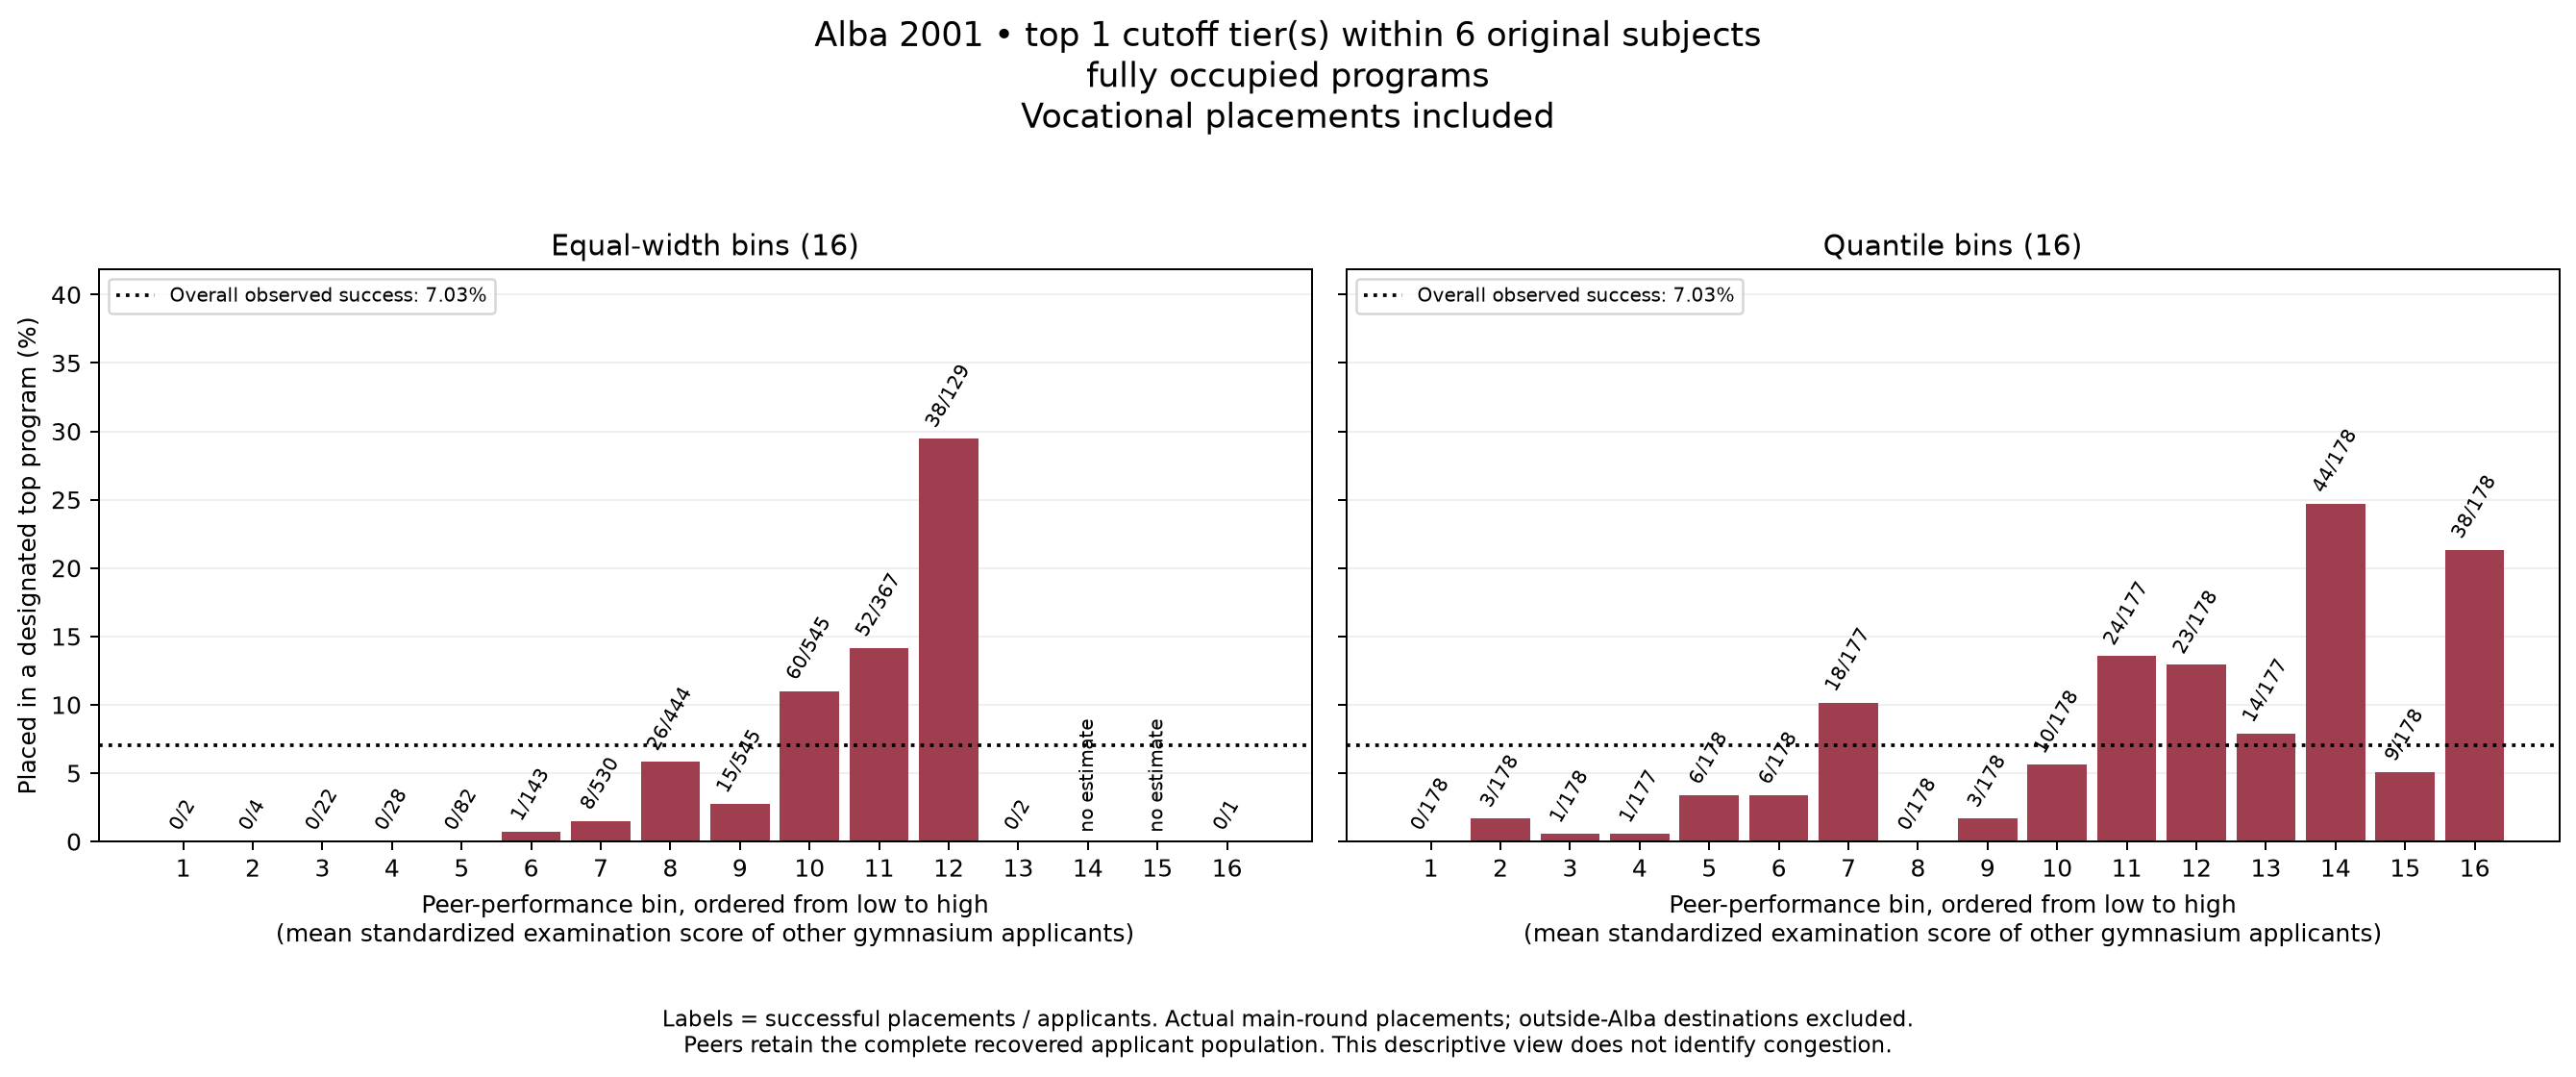

### comparison exclude vocational

200 successes / 2,624 applicants = 7.62%


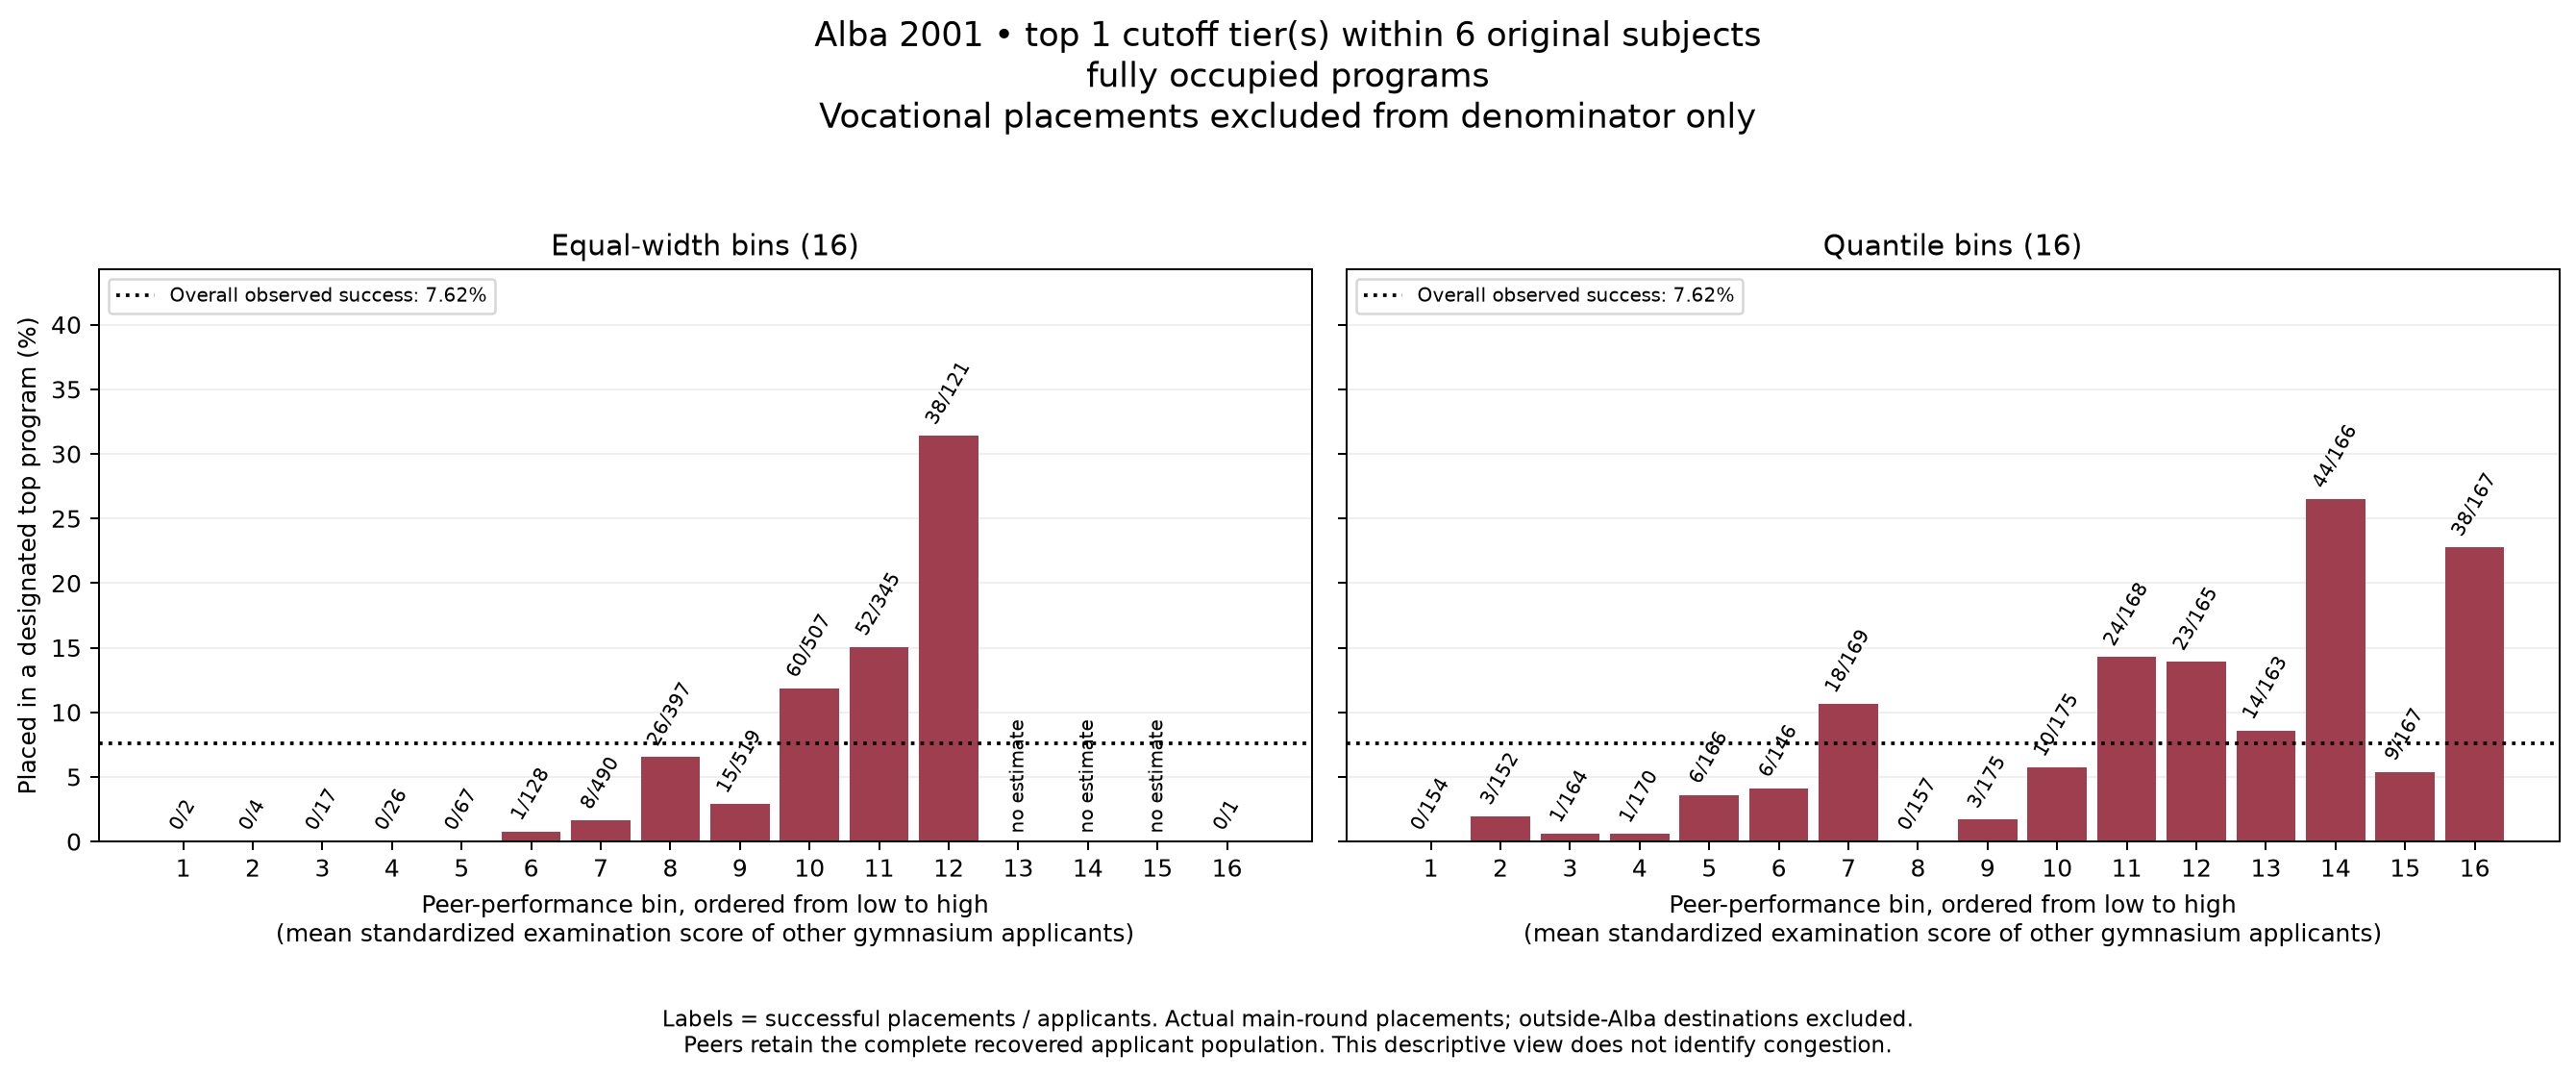

In [8]:
if result.get("status") == "completed":
    run_folder = Path(result["run_directory"])
    print("READ THIS REPORT:", run_folder / "report.md")
    print("Matching/exclusion counts:", run_folder / "matching_audit.json")
    print("Source and output hashes:", run_folder / "run_record.json")
    for name, details in result["variants"].items():
        display(Markdown("### " + name.replace("_", " ")))
        print(f"{details['successes']:,} successes / {details['N']:,} applicants "
              f"= {details['observed_success_fraction']:.2%}")
        display(Image(filename=details["figures"][0]))
else:
    print("Preview complete. No HERO run has occurred.")


## 9. Final bounded check: similar examination scores, different peer strength

This separate descriptive check uses the **exact success definition saved in Cell 1**. It asks:

> Among applicants with similar national-examination scores, did observed placement differ across weaker, middle, and stronger gymnasium peer environments?

Applicants are first placed into narrow bands of their own raw examination score. The fixed leave-one-out gymnasium peer measure is divided into three equally populated groups. A score band enters the pooled comparison only when all three peer groups contain enough applicants and distinct gymnasiums. The pooled rates then give all three peer groups the same own-score-band distribution.

This is still descriptive. Examination scores were measured after exposure to the gymnasium, applicants were not randomly assigned to gymnasiums, and students from one gymnasium are not independent replications.

In [9]:
# SETTINGS FOR THE SIMILAR-SCORE / PEER-STRENGTH COMPARISON
# These affect only Section 9. The placement outcome continues to use every
# setting already saved in Cell 1.

RUN_SIMILAR_SCORE_PEER_COMPARISON = True

# Example: with 0.25, scores from 8.00 through 8.24 form one band.
OWN_EXAM_SCORE_BAND_WIDTH = 0.25

# Fixed at three plain-language groups: weaker, middle, and stronger peers.
PEER_STRENGTH_GROUPS = 3

# Cells remain visible in the detailed CSV but enter the pooled comparison only
# when they meet BOTH support requirements.
MIN_APPLICANTS_PER_CELL = 10
MIN_GYMNASIUMS_PER_CELL = 3

# Save aggregate tables, the figure, settings, and a narrated report.
SAVE_SIMILAR_SCORE_RESULTS = True


In [10]:
# CODE IS RUNNING WHEN THIS CELL IS EXECUTED.
# Entirely offline: no scraping and no rerun of the earlier HERO plotting cell.

from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if not RUN_SIMILAR_SCORE_PEER_COMPARISON:
    print("Similar-score comparison is off. Nothing was calculated or saved.")
else:
    if OWN_EXAM_SCORE_BAND_WIDTH <= 0:
        raise ValueError("OWN_EXAM_SCORE_BAND_WIDTH must be positive.")
    if PEER_STRENGTH_GROUPS != 3:
        raise ValueError("This bounded check is intentionally fixed at three peer groups.")
    if MIN_APPLICANTS_PER_CELL < 1 or MIN_GYMNASIUMS_PER_CELL < 1:
        raise ValueError("Support minimums must be positive integers.")

    print("Similar-score check 1/4 — loading the Cell 1 placement definition.")
    current_settings = {
        "top_program_tiers": TOP_PROGRAM_TIERS,
        "require_full_programs": REQUIRE_FULL_PROGRAMS,
        "combine_program_categories": COMBINE_PROGRAM_CATEGORIES,
    }

    # Reuse Section 6 only if it reflects the current Cell 1 settings.
    saved_reconciliation = globals().get("reconciliation")
    reconciliation_matches = (
        saved_reconciliation is not None
        and saved_reconciliation[2].get("top_program_tiers") == TOP_PROGRAM_TIERS
        and reconciliation[2].get("require_full_programs") == REQUIRE_FULL_PROGRAMS
        and reconciliation[2].get("combine_program_categories") == COMBINE_PROGRAM_CATEGORIES
    )
    if reconciliation_matches:
        frame = saved_reconciliation[0].copy()
        print("  Reused the current Section 6 reconciliation.")
    else:
        print("  Rebuilding reconciliation offline because Section 6 is absent or stale.")
        frame, _, _, _ = hero.prepare_analysis(**current_settings)

    # The Cell 1 vocational choice changes only outcome eligibility. Excluded
    # applicants remain in other students' already-computed peer averages.
    population = hero.outcome_population(
        frame, include_vocational=INCLUDE_VOCATIONAL_IN_OUTCOME_DENOMINATOR
    )
    data = population.loc[
        population["included_in_outcome"],
        ["source_code", "analytic_row", "exam_score", "peer_mean_A_z", "success"]
    ].dropna().copy()
    data["success"] = data["success"].astype(int)
    if data.empty:
        raise ValueError("No eligible applicants remain under the Cell 1 settings.")

    print(f"  Eligible applicants: {len(data):,}")
    print(f"  Distinct gymnasiums: {data['source_code'].nunique():,}")
    print("Similar-score check 2/4 — making score bands and peer-strength groups.")

    # Use raw examination points so 'similar score' has a plain interpretation.
    width = float(OWN_EXAM_SCORE_BAND_WIDTH)
    lower = np.floor((data["exam_score"] + 1e-12) / width) * width
    data["score_band_lower"] = lower.round(10)
    data["score_band_upper"] = (lower + width).round(10)
    data["score_band"] = data.apply(
        lambda r: f"{r['score_band_lower']:.2f}–<{r['score_band_upper']:.2f}", axis=1
    )

    labels = ["Weaker peers", "Middle peers", "Stronger peers"]
    peer_code, peer_edges = pd.qcut(
        data["peer_mean_A_z"], q=3, labels=False, retbins=True, duplicates="drop"
    )
    if len(peer_edges) != 4:
        raise ValueError("Ties prevented creation of three peer-strength groups.")
    data["peer_group"] = pd.Categorical(
        [labels[int(i)] for i in peer_code], categories=labels, ordered=True
    )

    cells = (
        data.groupby(
            ["score_band_lower", "score_band_upper", "score_band", "peer_group"],
            observed=False,
        )
        .agg(
            applicants=("success", "size"),
            successes=("success", "sum"),
            gymnasiums=("source_code", "nunique"),
            mean_exam_score=("exam_score", "mean"),
            mean_peer_z=("peer_mean_A_z", "mean"),
        )
        .reset_index()
    )
    cells["placement_rate"] = cells["successes"] / cells["applicants"].replace(0, np.nan)
    cells["adequate_support"] = (
        (cells["applicants"] >= MIN_APPLICANTS_PER_CELL)
        & (cells["gymnasiums"] >= MIN_GYMNASIUMS_PER_CELL)
    )

    # Common support requires adequate evidence in all three peer groups inside
    # the same own-score band.
    support = cells.groupby("score_band", observed=False)["adequate_support"].sum()
    common_bands = support[support == 3].index.tolist()
    common = cells.loc[
        cells["score_band"].isin(common_bands) & cells["adequate_support"]
    ].copy()
    if not common_bands:
        raise ValueError(
            "No score band has adequate support in all three peer groups. "
            "Inspect the detailed cells before cautiously changing settings."
        )

    # Give all peer groups the same own-score-band mix. This stops a group from
    # appearing better merely because it has more high-scoring applicants.
    weights = (
        data.loc[data["score_band"].isin(common_bands)]
        .groupby("score_band", observed=False).size()
        .rename("band_N").reset_index()
    )
    weights = weights.loc[weights["band_N"] > 0].copy()
    weights["common_weight"] = weights["band_N"] / weights["band_N"].sum()
    common = common.merge(
        weights[["score_band", "common_weight"]],
        on="score_band", how="left", validate="many_to_one"
    )
    common["weighted_rate_piece"] = common["placement_rate"] * common["common_weight"]

    adjusted = (
        common.groupby("peer_group", observed=False)
        .agg(
            adjusted_placement_rate=("weighted_rate_piece", "sum"),
            observed_applicants=("applicants", "sum"),
            observed_successes=("successes", "sum"),
            score_bands=("score_band", "nunique"),
        )
        .reset_index()
    )
    gyms = (
        data.loc[data["score_band"].isin(common_bands)]
        .groupby("peer_group", observed=False)["source_code"].nunique()
        .rename("distinct_gymnasiums").reset_index()
    )
    adjusted = adjusted.merge(gyms, on="peer_group", how="left")
    weak = float(adjusted.loc[
        adjusted["peer_group"] == "Weaker peers", "adjusted_placement_rate"
    ].iloc[0])
    strong = float(adjusted.loc[
        adjusted["peer_group"] == "Stronger peers", "adjusted_placement_rate"
    ].iloc[0])
    difference = strong - weak

    print("Similar-score check 3/4 — adjusted comparison complete.")
    print(f"  Common-support score bands: {len(common_bands)}")
    print(f"  Stronger minus weaker peers: {difference:+.2%}")
    display(adjusted)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    colors = {
        "Weaker peers": "#6baed6",
        "Middle peers": "#969696",
        "Stronger peers": "#a63d4f",
    }
    for label in labels:
        part = common.loc[common["peer_group"] == label].sort_values("score_band_lower")
        axes[0].plot(
            part["score_band_lower"] + width / 2,
            part["placement_rate"] * 100,
            marker="o", linewidth=1.8, label=label, color=colors[label],
        )
    axes[0].set_title("Rates within similar examination-score bands")
    axes[0].set_xlabel("Own examination score (band midpoint)")
    axes[0].set_ylabel("Placed in a designated program (%)")
    axes[0].grid(axis="y", alpha=0.25)
    axes[0].legend()

    bars = axes[1].bar(
        adjusted["peer_group"].astype(str),
        adjusted["adjusted_placement_rate"] * 100,
        color=[colors[x] for x in labels],
    )
    axes[1].set_title("Same score-band mix for every peer group")
    axes[1].set_ylabel("Score-band-adjusted placement (%)")
    axes[1].grid(axis="y", alpha=0.25)
    for bar, rate in zip(bars, adjusted["adjusted_placement_rate"]):
        axes[1].text(
            bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{rate:.1%}", ha="center", va="bottom"
        )
    axes[1].tick_params(axis="x", rotation=12)

    occupancy = "full only" if REQUIRE_FULL_PROGRAMS else "full + partially filled"
    categories = "3 combined groups" if COMBINE_PROGRAM_CATEGORIES else "6 original subjects"
    fig.suptitle(
        "Alba 2001: placement by peer strength among similarly scoring applicants\n"
        f"Cell 1: top {TOP_PROGRAM_TIERS} tier(s); {occupancy}; {categories}"
    )
    fig.text(
        .5, .01,
        "Descriptive association only; examination score is post-gymnasium and assignment is not random.",
        ha="center", fontsize=9
    )
    fig.tight_layout(rect=(0, .05, 1, .91))

    comparison_result = {
        "eligible_applicants": int(len(data)),
        "common_score_bands": int(len(common_bands)),
        "weaker_peer_adjusted_rate": weak,
        "stronger_peer_adjusted_rate": strong,
        "stronger_minus_weaker": difference,
    }

    print("Similar-score check 4/4 — figure built.")
    if SAVE_SIMILAR_SCORE_RESULTS:
        parent = EDUCATION_ROOT / "outputs" / "romania_alba_2001_similar_score_peer_comparison"
        run_folder = parent / datetime.now(timezone.utc).strftime("run_%Y%m%dT%H%M%S_%fZ")
        run_folder.mkdir(parents=True, exist_ok=False)
        cells.to_csv(run_folder / "all_score_band_peer_cells.csv", index=False)
        common.to_csv(run_folder / "common_support_cells.csv", index=False)
        adjusted.to_csv(run_folder / "adjusted_peer_group_rates.csv", index=False)
        fig.savefig(run_folder / "similar_score_peer_comparison.png", dpi=180, bbox_inches="tight")
        fig.savefig(run_folder / "similar_score_peer_comparison.pdf", bbox_inches="tight")

        summary = {
            **current_settings,
            "include_vocational_in_outcome_denominator":
                INCLUDE_VOCATIONAL_IN_OUTCOME_DENOMINATOR,
            "own_exam_score_band_width": OWN_EXAM_SCORE_BAND_WIDTH,
            "peer_strength_groups": PEER_STRENGTH_GROUPS,
            "minimum_applicants_per_cell": MIN_APPLICANTS_PER_CELL,
            "minimum_gymnasiums_per_cell": MIN_GYMNASIUMS_PER_CELL,
            **comparison_result,
        }
        hero.write_json(run_folder / "settings_and_summary.json", summary)

        report_lines = [
            "# Alba 2001 — similar examination scores, different gymnasium peers", "",
            "## Question", "",
            "Among applicants with similar national-examination scores, did observed "
            "placement differ across weaker, middle, and stronger gymnasium peer environments?", "",
            "## Construction", "",
            f"- Cell 1 placement definition: top {TOP_PROGRAM_TIERS} cutoff tier(s); "
            f"{occupancy}; {categories}.",
            f"- Raw examination-score band width: {OWN_EXAM_SCORE_BAND_WIDTH:.2f}.",
            f"- Minimum support in every cell: {MIN_APPLICANTS_PER_CELL} applicants and "
            f"{MIN_GYMNASIUMS_PER_CELL} gymnasiums.",
            "- All peer groups were reweighted to the same own-score-band distribution.", "",
            "## Result", "",
            f"- Eligible applicants: {len(data):,}.",
            f"- Common-support examination-score bands: {len(common_bands)}.",
            f"- Weaker-peer adjusted placement rate: {weak:.2%}.",
            f"- Stronger-peer adjusted placement rate: {strong:.2%}.",
            f"- Stronger minus weaker: {difference:+.2%}.", "",
            "## Interpretation limit", "",
            "This is a descriptive conditional association. It does not prove that gymnasium "
            "peers caused placement differences. Examination scores were measured after time "
            "in the gymnasium; students were not randomly assigned; students from one gymnasium "
            "are not independent replications; and geography, preferences, school grades, or "
            "other unobserved differences may remain.", "",
            "No alternative band widths or support thresholds were searched automatically.", "",
        ]
        (run_folder / "report.md").write_text("\n".join(report_lines), encoding="utf-8")
        comparison_result["run_directory"] = str(run_folder)
        print("  Results saved:", run_folder)
        print("  Read:", run_folder / "report.md")
    else:
        print("  SAVE_SIMILAR_SCORE_RESULTS is False; nothing was written.")

    display(fig)
    plt.close(fig)


Similar-score check 1/4 — loading the Cell 1 placement definition.
  Reused the current Section 6 reconciliation.
  Eligible applicants: 2,624
  Distinct gymnasiums: 148
Similar-score check 2/4 — making score bands and peer-strength groups.
Similar-score check 3/4 — adjusted comparison complete.
  Common-support score bands: 17
  Stronger minus weaker peers: +6.50%


,peer_group,adjusted_placement_rate,observed_applicants,observed_successes,score_bands,distinct_gymnasiums
0,Weaker peers,0.031701,860,14,17,107
1,Middle peers,0.046752,858,40,17,59
2,Stronger peers,0.096721,833,115,17,31


Similar-score check 4/4 — figure built.
  Results saved: /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/3-Master_Plan/VECTOR_work/new_VECTOR_work/education_analysis/outputs/romania_alba_2001_similar_score_peer_comparison/run_20260930T193232_648410Z
  Read: /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/3-Master_Plan/VECTOR_work/new_VECTOR_work/education_analysis/outputs/romania_alba_2001_similar_score_peer_comparison/run_20260930T193232_648410Z/report.md


<Figure size 1400x550 with 2 Axes>

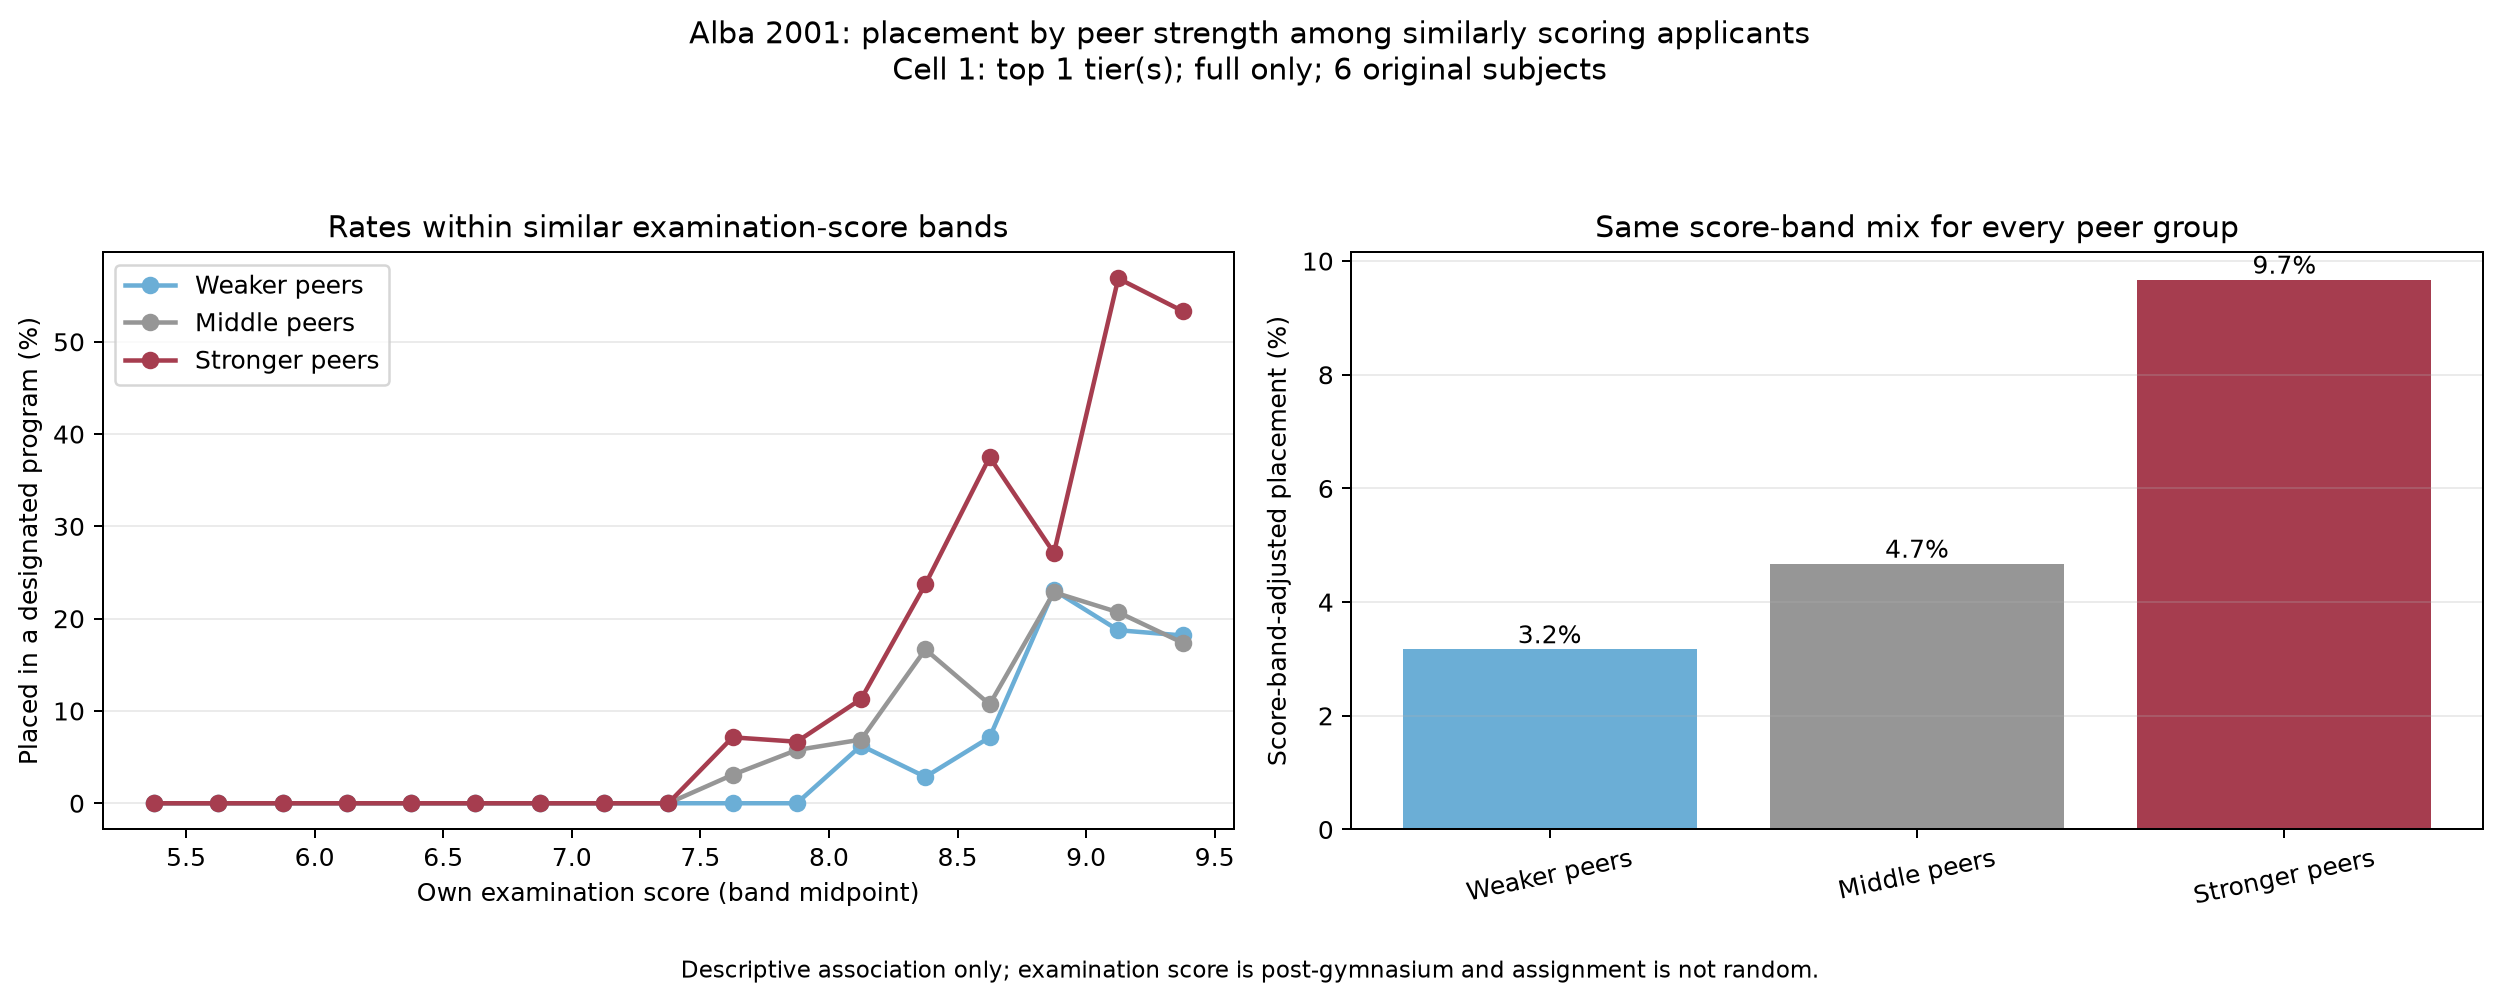

In [11]:
display(Image(
    filename=str(
        Path(comparison_result["run_directory"])
        / "similar_score_peer_comparison.png"
    )
))

## 10. Fixed individual-performance bands across gymnasium peer strength

This standalone offline section reconstructs the current Cell 1 population and rotates the view to match the conditional logic of data-story Panels 7 and 8:

- **Horizontal axis:** leave-one-out gymnasium peer strength, \(T_{-i}\).
- **Vertical axis:** observed placement success.
- **Colored lines:** fixed bands of the applicant's own standardized examination performance, \(A_i\).

The red line is the top 10% of applicants. The orange line immediately below it—the 75th through 90th percentiles—is the proposed **band of excellence**: excellent applicants who are not the nearly automatic top tail. A downturn in that orange line as \(T_{-i}\) becomes very high would be the descriptive pattern of interest. The chart does not assume that such a downturn exists.

This remains descriptive. It does not convert gymnasium sorting into random assignment or establish a causal congestion effect.

In [12]:
# SETTINGS FOR FIXED A_i BANDS ACROSS T_j
# This section independently reconstructs the eligible population using the
# current Cell 1 success definition. Section 9 does not need to be run first.

RUN_FIXED_AI_ACROSS_TJ_PLOT = True
TJ_QUANTILE_BINS = 8

# Lower 50%, 50–75%, band of excellence 75–90%, and top 10%.
AI_PERCENTILE_CUTS = [0.00, 0.50, 0.75, 0.90, 1.00]

# Unsupported points remain in the audit CSV but are omitted from the plot.
MIN_APPLICANTS_PER_FIXED_AI_TJ_CELL = 10
MIN_GYMNASIUMS_PER_FIXED_AI_TJ_CELL = 3

SAVE_FIXED_AI_ACROSS_TJ_RESULTS = True


Fixed-A_i plot 1/3 — reconstructing the Cell 1 population.
  Reused the current Section 6 reconciliation.
  Eligible applicants: 2,624
  Distinct gymnasiums: 148
  Creating A_i bands and T_j bins.
  Empirical A_i z-score boundaries:


,boundary_percentile,A_z_cutoff
0,0.00,-1.774119
1,0.50,0.032341
2,0.75,0.901487
3,0.90,1.540565
4,1.00,2.358585


  Every plotted point has at least 10 applicants and 3 gymnasiums.
Fixed-A_i plot 2/3 — drawing supported placement curves.
Fixed-A_i plot 3/3 — figure built.
  Saved: /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/3-Master_Plan/VECTOR_work/new_VECTOR_work/education_analysis/outputs/romania_alba_2001_fixed_Ai_across_Tj/run_20260930T193232_982466Z/fixed_Ai_across_Tj.png


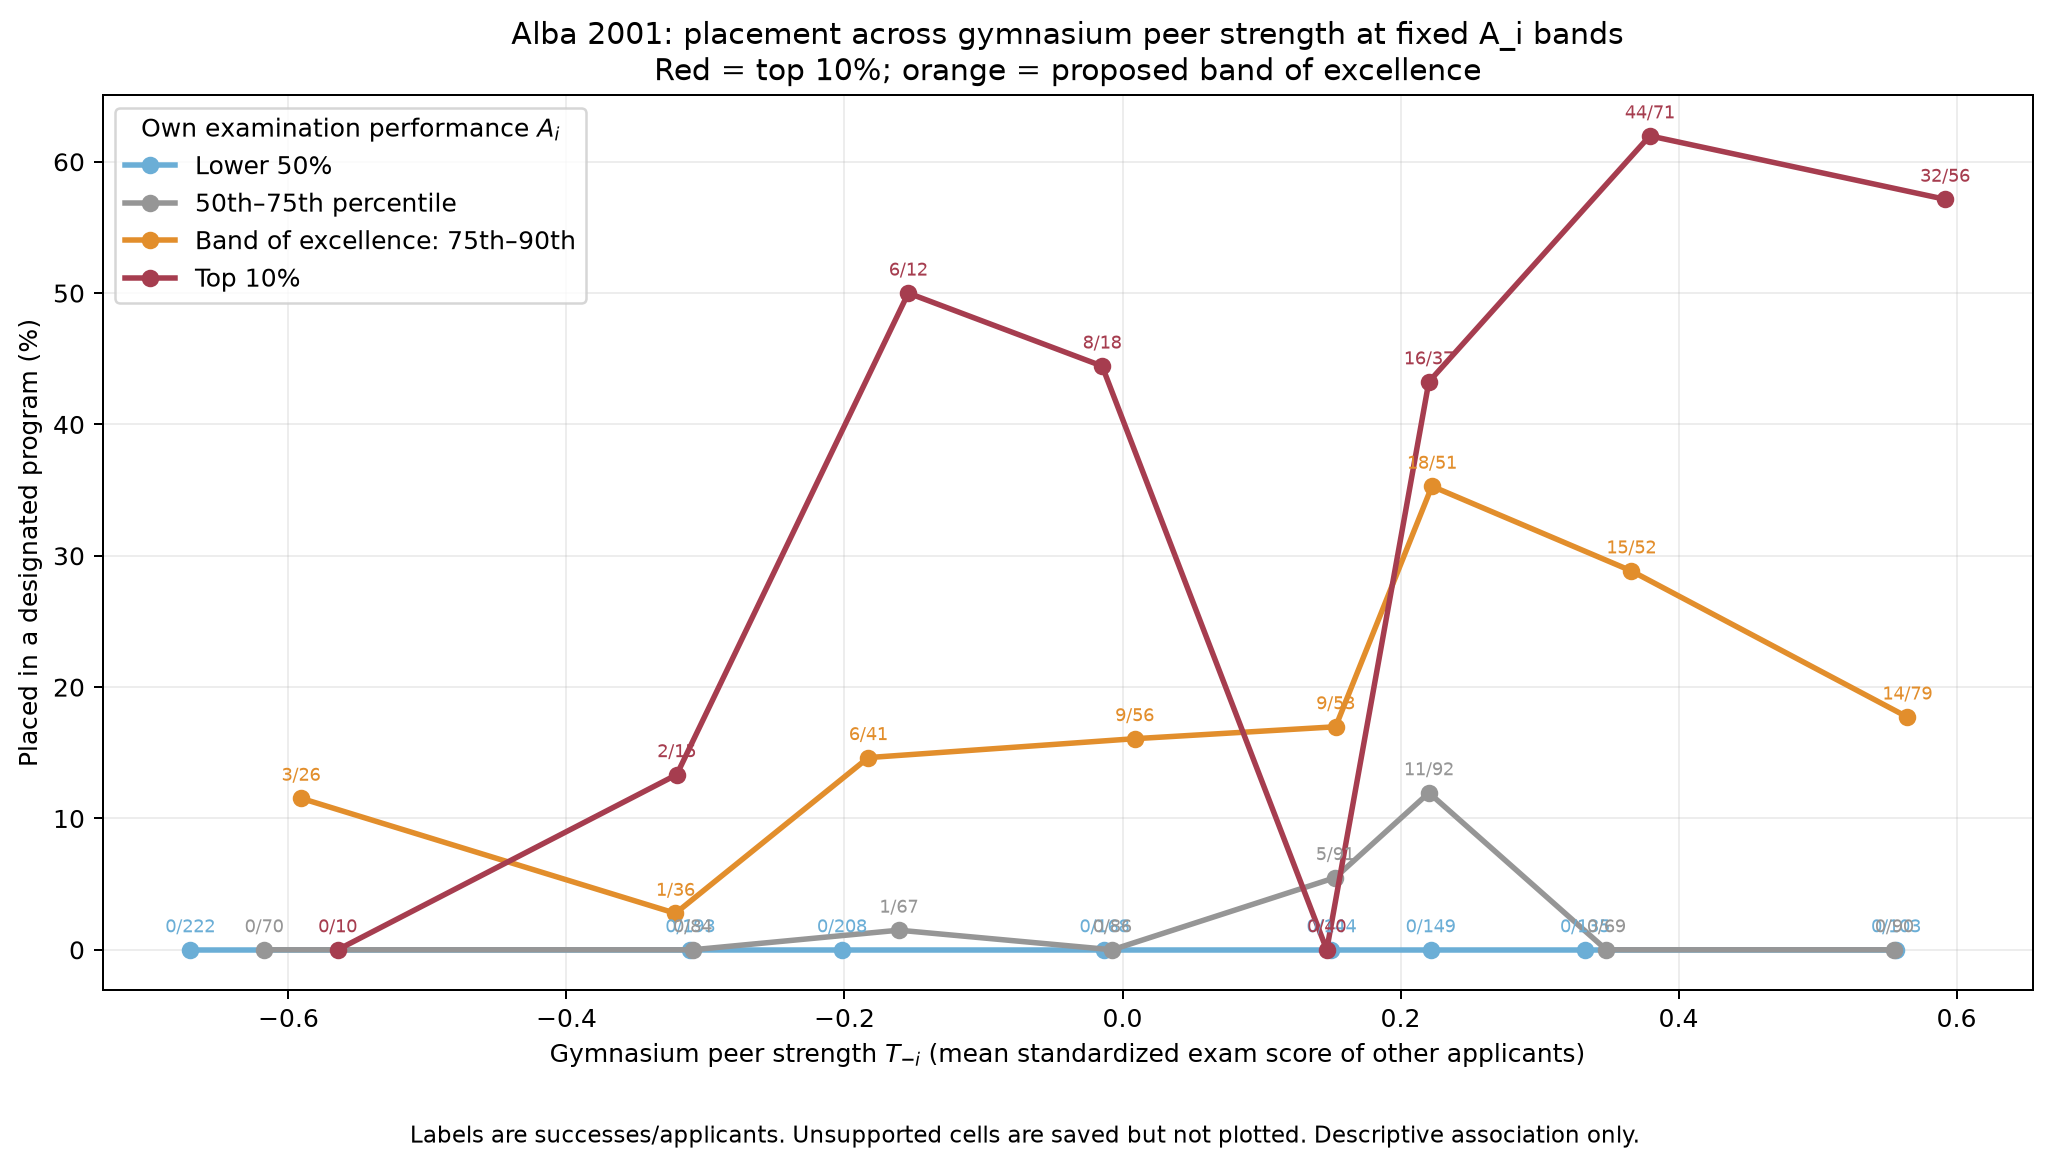

In [13]:
# CODE IS RUNNING WHEN THIS CELL IS EXECUTED.
# Offline only. This cell reconstructs the Cell 1 population by itself.

from datetime import datetime, timezone
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

if not RUN_FIXED_AI_ACROSS_TJ_PLOT:
    print("Fixed-A_i / T_j plot is switched off.")
else:
    if "hero" not in globals():
        raise RuntimeError("Run Section 2 first so the repository code is loaded.")
    if TJ_QUANTILE_BINS < 3:
        raise ValueError("TJ_QUANTILE_BINS must be at least 3.")
    if AI_PERCENTILE_CUTS != [0.00, 0.50, 0.75, 0.90, 1.00]:
        raise ValueError("This first view is locked to the documented four A_i bands.")

    print("Fixed-A_i plot 1/3 — reconstructing the Cell 1 population.")
    current_settings = {
        "top_program_tiers": TOP_PROGRAM_TIERS,
        "require_full_programs": REQUIRE_FULL_PROGRAMS,
        "combine_program_categories": COMBINE_PROGRAM_CATEGORIES,
    }
    saved_reconciliation = globals().get("reconciliation")
    reconciliation_matches = (
        saved_reconciliation is not None
        and saved_reconciliation[2].get("top_program_tiers") == TOP_PROGRAM_TIERS
        and saved_reconciliation[2].get("require_full_programs") == REQUIRE_FULL_PROGRAMS
        and saved_reconciliation[2].get("combine_program_categories") == COMBINE_PROGRAM_CATEGORIES
    )
    if reconciliation_matches:
        frame = saved_reconciliation[0].copy()
        print("  Reused the current Section 6 reconciliation.")
    else:
        print("  Rebuilding reconciliation offline from the saved reports.")
        frame, _, _, _ = hero.prepare_analysis(**current_settings)

    population = hero.outcome_population(
        frame, include_vocational=INCLUDE_VOCATIONAL_IN_OUTCOME_DENOMINATOR
    )
    fixed = population.loc[
        population["included_in_outcome"],
        ["source_code", "A_z", "peer_mean_A_z", "success"]
    ].dropna().copy()
    fixed["success"] = fixed["success"].astype(int)
    if fixed.empty:
        raise ValueError("No eligible applicants remain under the Cell 1 settings.")
    print(f"  Eligible applicants: {len(fixed):,}")
    print(f"  Distinct gymnasiums: {fixed['source_code'].nunique():,}")
    print("  Creating A_i bands and T_j bins.")

    ai_labels = [
        "Lower 50%",
        "50th–75th percentile",
        "Band of excellence: 75th–90th",
        "Top 10%",
    ]
    ai_edges = fixed["A_z"].quantile(AI_PERCENTILE_CUTS).to_numpy()
    if len(np.unique(ai_edges)) != len(ai_edges):
        raise ValueError("Tied A_i values prevented formation of the requested bands.")
    fixed["ai_band"] = pd.cut(
        fixed["A_z"], bins=ai_edges, labels=ai_labels,
        include_lowest=True, ordered=True
    )

    tj_code, tj_edges = pd.qcut(
        fixed["peer_mean_A_z"], q=TJ_QUANTILE_BINS,
        labels=False, retbins=True, duplicates="drop"
    )
    if len(tj_edges)-1 != TJ_QUANTILE_BINS:
        raise ValueError("Tied T_j values prevented the requested number of bins.")
    fixed["tj_bin"] = tj_code.astype(int) + 1

    fixed_cells = (
        fixed.groupby(["ai_band", "tj_bin"], observed=False)
        .agg(
            applicants=("success", "size"),
            successes=("success", "sum"),
            gymnasiums=("source_code", "nunique"),
            mean_A_i=("A_z", "mean"),
            mean_T_j=("peer_mean_A_z", "mean"),
        )
        .reset_index()
    )
    fixed_cells["placement_rate"] = (
        fixed_cells["successes"] / fixed_cells["applicants"].replace(0, np.nan)
    )
    fixed_cells["adequate_support"] = (
        (fixed_cells["applicants"] >= MIN_APPLICANTS_PER_FIXED_AI_TJ_CELL)
        & (fixed_cells["gymnasiums"] >= MIN_GYMNASIUMS_PER_FIXED_AI_TJ_CELL)
    )

    ai_cutoffs = pd.DataFrame({
        "boundary_percentile": AI_PERCENTILE_CUTS,
        "A_z_cutoff": ai_edges,
    })
    print("  Empirical A_i z-score boundaries:")
    display(ai_cutoffs)
    print(
        "  Every plotted point has at least "
        f"{MIN_APPLICANTS_PER_FIXED_AI_TJ_CELL} applicants and "
        f"{MIN_GYMNASIUMS_PER_FIXED_AI_TJ_CELL} gymnasiums."
    )

    print("Fixed-A_i plot 2/3 — drawing supported placement curves.")
    colors = {
        "Lower 50%": "#6baed6",
        "50th–75th percentile": "#969696",
        "Band of excellence: 75th–90th": "#e28e2c",
        "Top 10%": "#a63d4f",
    }
    fig3, ax = plt.subplots(figsize=(11.5, 6.5))
    for label in ai_labels:
        part = fixed_cells.loc[
            (fixed_cells["ai_band"] == label) & fixed_cells["adequate_support"]
        ].sort_values("tj_bin")
        ax.plot(
            part["mean_T_j"], part["placement_rate"]*100,
            marker="o", linewidth=2.2, markersize=6,
            color=colors[label], label=label
        )
        for _, row in part.iterrows():
            ax.annotate(
                f"{int(row['successes'])}/{int(row['applicants'])}",
                (row["mean_T_j"], row["placement_rate"]*100),
                xytext=(0,7), textcoords="offset points",
                ha="center", fontsize=7, color=colors[label]
            )

    ax.set_title(
        "Alba 2001: placement across gymnasium peer strength at fixed A_i bands\n"
        "Red = top 10%; orange = proposed band of excellence"
    )
    ax.set_xlabel(
        r"Gymnasium peer strength $T_{-i}$ "
        "(mean standardized exam score of other applicants)"
    )
    ax.set_ylabel("Placed in a designated program (%)")
    ax.grid(axis="both", alpha=.22)
    ax.legend(title="Own examination performance $A_i$")
    fig3.text(
        .5,.015,
        "Labels are successes/applicants. Unsupported cells are saved but not plotted. "
        "Descriptive association only.",
        ha="center", fontsize=9
    )
    fig3.tight_layout(rect=(0,.055,1,1))

    print("Fixed-A_i plot 3/3 — figure built.")
    fixed_ai_result = {
        "A_i_cutoffs": ai_cutoffs.to_dict(orient="records"),
        "T_j_bin_edges": [float(x) for x in tj_edges],
        "plotted_cells": int(fixed_cells["adequate_support"].sum()),
        "all_cells": int(len(fixed_cells)),
    }

    if SAVE_FIXED_AI_ACROSS_TJ_RESULTS:
        parent = EDUCATION_ROOT / "outputs" / "romania_alba_2001_fixed_Ai_across_Tj"
        run_folder = parent / datetime.now(timezone.utc).strftime("run_%Y%m%dT%H%M%S_%fZ")
        run_folder.mkdir(parents=True, exist_ok=False)
        fixed_cells.to_csv(run_folder/"fixed_Ai_across_Tj_cells.csv", index=False)
        ai_cutoffs.to_csv(run_folder/"fixed_Ai_band_boundaries.csv", index=False)
        fixed_ai_png = run_folder/"fixed_Ai_across_Tj.png"
        fig3.savefig(fixed_ai_png, dpi=180, bbox_inches="tight")
        fig3.savefig(run_folder/"fixed_Ai_across_Tj.pdf", bbox_inches="tight")
        hero.write_json(
            run_folder/"fixed_Ai_across_Tj_settings.json",
            {
                "tj_quantile_bins": TJ_QUANTILE_BINS,
                "ai_percentile_cuts": AI_PERCENTILE_CUTS,
                "minimum_applicants_per_cell":
                    MIN_APPLICANTS_PER_FIXED_AI_TJ_CELL,
                "minimum_gymnasiums_per_cell":
                    MIN_GYMNASIUMS_PER_FIXED_AI_TJ_CELL,
                **fixed_ai_result,
            },
        )
        fixed_ai_result["run_directory"] = str(run_folder)
        print("  Saved:", fixed_ai_png)
        # Cursor sometimes prints only a Figure label; load the saved PNG.
        display(Image(filename=str(fixed_ai_png)))
    else:
        plt.show()
    plt.close(fig3)
